# Homework 1: Analytics for COVID-19 mortality risk

Dear Students,

Welcome to our first homework assignment, where we'll tackle an important real-world challenge: predicting COVID-19 mortality risk using machine learning. Although the pandemic is not making the news as much, the virus is still present all over the world and analytics can help save lives. This assignment serves as a great introduction to our course's journey from traditional machine learning methods to advanced neural architectures, all while working on a problem that has immediate societal impact.

In this assignment, you'll develop predictive models that could help healthcare providers make more informed decisions about patient care. We'll start with interpretable models like decision trees, progress to more sophisticated ensemble methods like random forests and gradient boosting, and culminate in implementing neural networks.

What makes this assignment particularly valuable is its focus on:

- Real Healthcare Impact: Your models could help hospitals optimize resource allocation and identify high-risk patients who need immediate attention.
- Model Comparison: You'll gain hands-on experience comparing different ML approaches, from highly interpretable decision trees to complex neural networks, understanding the trade-offs between model complexity and performance.
- Practical Skills: You'll work with real patient data, implement cross-validation, tune hyperparameters, and evaluate models using healthcare-relevant metrics - all essential skills for your future career in ML.
- Model Interpretability: Through SHAP plots and feature importance analysis, you'll learn to explain your models' decisions, a crucial skill when working with healthcare professionals.

This assignment sets the foundation for our later explorations into computer vision, NLP, and multimodal learning. By mastering these fundamental concepts in a healthcare context, you'll be better prepared to tackle more complex challenges as we progress through the courses.

*Important Assignment Instructions*

Please make sure to directly write your code and any accompanying text responses in your notebook. While you are welcome to use Large Language Models (LLMs) to assist you with coding tasks, you are not allowed to use them for interpreting results or writing your first draft of the executive summary section (minor editing okay). It is also essential that you read the entire assignment carefully before beginning any question to ensure that you understand all requirements and instructions.

**Please use the random seed 42** for all your cross-validations and any method that involves randomness.

Happy coding and good luck with your analysis!

## Predicting Patient Mortality with Decision Trees, Random Forests, Boosted Trees and Neural Networks

The primary objective of our study is to predict patient mortality ("DEATH") using various health-related features from a dataset of anonymized patient information. This dataset includes features like age, sex, and medical history details such as diabetes, hypertension, and COVID-19 status. We aim to employ decision tree and random forest algorithms to construct predictive models. Decision trees will help us understand the importance and influence of each feature on the outcome by breaking down the data into smaller subsets, while random forests, which are ensembles of decision trees, will enhance the prediction accuracy. These methods are chosen for their ability to handle large datasets and their efficacy in interpreting complex, nonlinear relationships that may exist among the features.

## Impact of the Predictive Modeling

Predicting patient mortality using decision trees and random forests is not only a crucial advancement in healthcare analytics but also a meaningful contribution to medical practice and patient management. This predictive modeling provides several impactful benefits:

1. **Proactive Patient Care**: By accurately forecasting mortality risks, healthcare providers can prioritize interventions for high-risk patients, potentially improving outcomes through timely and targeted treatments.

2. **Resource Allocation**: Hospitals and healthcare facilities can optimize their resource allocation—such as ICU beds, specialized staff, and critical care equipment—based on predicted patient needs. This is especially vital during crises like pandemics when resources are stretched thin.

3. **Personalized Medicine**: The insights from these models help in personalizing patient care plans. Understanding how different variables contribute to health risks allows clinicians to tailor medical advice and treatment plans to individual patient profiles.

4. **Policy and Planning**: Insights from mortality predictions can inform health policy decisions, helping public health officials plan and implement strategies for disease prevention and health promotion more effectively.

5. **Improving Healthcare Outcomes**: Ultimately, the goal is to reduce mortality rates and improve the quality of life for patients by leveraging data-driven insights to inform clinical decisions.

By harnessing the power of machine learning in analyzing complex datasets, this approach stands to significantly impact patient outcomes and the efficiency of healthcare systems globally.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## About The Dataset

#### This dataset contains an enormous number of anonymized patient-related information including pre-conditions. The raw dataset consists of 21 unique features and 1,048,576 unique patients. In the Boolean features, 0 means "no" and 1 means "yes".

- **SEX**: male (0) or female (1)
- **AGE**: of the patient.
- **COVID_POSITIVE**: value 1 means that the patient was diagnosed with COVID. 0 means that the patient is not a carrier of COVID or that the test is inconclusive.
- **HOSPITALIZED**: hospitalized (1) or not hospitalized (0).
- **PNEUMONIA**: whether the patient already has air sacs inflammation or not.
- **PREGNANCY**: whether the patient is pregnant or not.
- **DIABETES**: whether the patient has diabetes or not.
- **COPD**: Indicates whether the patient has Chronic Obstructive Pulmonary Disease or not.
- **ASTHMA**: whether the patient has asthma or not.
- **IMMUNOSUPPRESSION**: whether the patient is immunosuppressed or not.
- **HYPERTENSION**: whether the patient has hypertension or not.
- **CARDIOVASCULAR**: whether the patient has heart or blood vessels related disease.
- **RENAL CHRONIC**: whether the patient has chronic renal disease or not.
- **OTHER DISEASE**: whether the patient has other disease or not.
- **OBESITY**: whether the patient is obese or not.
- **TOBACCO**: whether the patient is a tobacco user.
- **DEATH**: indicates whether the patient died or recovered.


## Load and Visualize Dataset

In [2]:
file_id = '1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE'
download_link = f"https://drive.google.com/uc?id={file_id}"

!wget -O covid.csv '{download_link}'

--2026-03-09 06:55:04--  https://drive.google.com/uc?id=1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE
Resolving drive.google.com (drive.google.com)... 172.253.118.139, 172.253.118.100, 172.253.118.113, ...
Connecting to drive.google.com (drive.google.com)|172.253.118.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE [following]
--2026-03-09 06:55:05--  https://drive.usercontent.google.com/download?id=1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.200.132, 2404:6800:4003:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.200.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35744174 (34M) [application/octet-stream]
Saving to: ‘covid.csv’

covid.csv           100%[===================>]  34.09M  50.8MB/s    in 0.7s    

2026-03-09 06:55:08 (50.8 MB/s) 

In [3]:
data = pd.read_csv("covid.csv", usecols=lambda column: column not in ['Unnamed: 0'])
print("Shape of data :",data.shape)
data.head()

Shape of data : (1021977, 17)


,SEX,HOSPITALIZED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,IMMUNOSUPPRESSION,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,COVID_POSITIVE,DEATH
0,1,0,1,65,0,0,0,0,0,1,0,0,0,0,0,1,1
1,0,0,1,72,0,0,0,0,0,1,0,0,1,1,0,0,1
2,0,1,0,55,0,1,0,0,0,0,0,0,0,0,0,1,1
3,1,0,0,53,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,68,0,1,0,0,0,1,0,0,0,0,0,1,1


In [4]:
data.describe()

,SEX,HOSPITALIZED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,IMMUNOSUPPRESSION,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,COVID_POSITIVE,DEATH
count,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06
mean,4.990729e-01,1.874719e-01,1.344091e-01,4.189535e+01,7.672384e-03,1.195448e-01,1.404924e-02,2.976192e-02,1.326644e-02,1.558372e-01,2.650157e-02,1.965406e-02,1.532265e-01,1.792604e-02,8.076307e-02,3.792610e-01,7.305155e-02
std,4.999994e-01,3.902901e-01,3.410915e-01,1.674953e+01,8.725552e-02,3.244286e-01,1.176940e-01,1.699299e-01,1.144135e-01,3.627011e-01,1.606215e-01,1.388085e-01,3.602059e-01,1.326828e-01,2.724710e-01,4.852034e-01,2.602212e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.000000e+00,0.000000e+00,0.000000e+00,5.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.210000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


I cleaned the dataset beforehand but the dataset is so large that we will use only a subset of the rows to make everything faster for the purpose of this homework.

Let's plot a histogram of the distribution of deaths in the data.

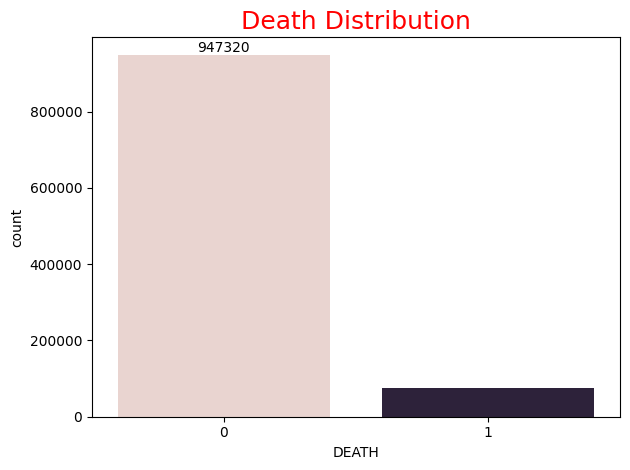

In [5]:
# Create the plot
ax = sns.countplot(x='DEATH', data=data, palette=sns.cubehelix_palette(2))
plt.bar_label(ax.containers[0])
plt.title("Death Distribution", fontsize=18, color="red")
plt.tight_layout()

To avoid issues with an unbalanced dataset, we select 5000 patients who died and 5000 patients who lived.

In [6]:
death_1_sample = data[data['DEATH'] == 1].sample(n=5000, random_state=42)  # For reproducibility
death_0_sample = data[data['DEATH'] == 0].sample(n=5000, random_state=42)

# Combine the samples into one DataFrame
df = pd.concat([death_1_sample, death_0_sample])

### Number of unique values by columns

In [7]:
for i in df.columns:
    print(i,"=>\t",len(df[i].unique()))

SEX =>	 2
HOSPITALIZED =>	 2
PNEUMONIA =>	 2
AGE =>	 104
PREGNANT =>	 2
DIABETES =>	 2
COPD =>	 2
ASTHMA =>	 2
IMMUNOSUPPRESSION =>	 2
HYPERTENSION =>	 2
OTHER_DISEASE =>	 2
CARDIOVASCULAR =>	 2
OBESITY =>	 2
RENAL_CHRONIC =>	 2
TOBACCO =>	 2
COVID_POSITIVE =>	 2
DEATH =>	 2


# Part 1: Data Visualization (20 points)

### 2. (2 points) Histogram

Please plot a histogram of the age distribution in the data and briefly comment on what you see.

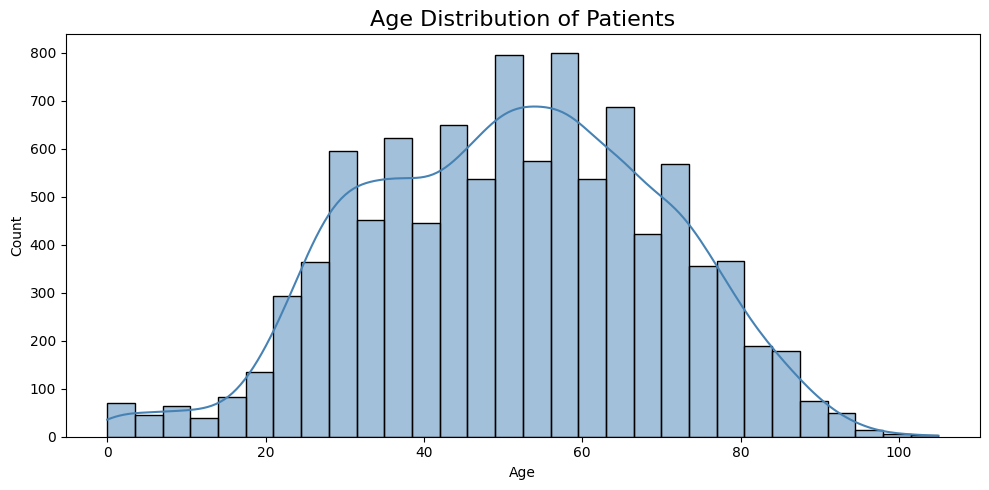

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['AGE'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Patients', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Visualization Explanation:**

The age distribution is roughly bell-shaped and centered around 45-65 years old, with relatively few patients under 20. The KDE curve confirms a slight right skew, meaning older patients are well-represented in this dataset—an important consideration given that age is one of the strongest known risk factors for COVID-19 mortality.

### 2. (3 points) Boxplot

Please make a boxplot showing the age distribution of the people who lived and died and interpret/comment on what you see. Hint: use seaborn and the function sns.boxplot.

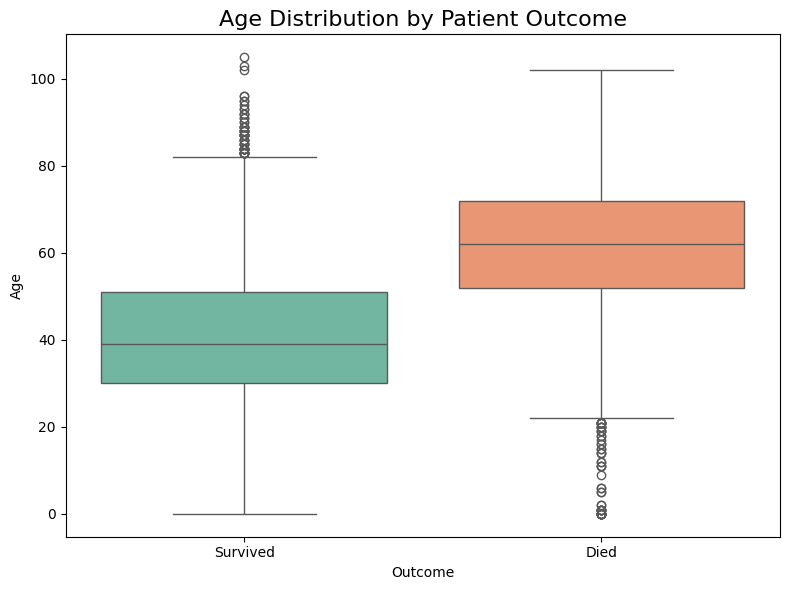

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='DEATH', y='AGE', data=df, palette='Set2')
plt.xticks([0, 1], ['Survived', 'Died'])
plt.title('Age Distribution by Patient Outcome', fontsize=16)
plt.xlabel('Outcome')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

**Visualization Explanation:**

Patients who died show a noticeably higher median age and a wider interquartile range compared to survivors, confirming that older patients faced significantly greater mortality risk. The overlap between the two groups also suggests age alone is not sufficient for prediction, which motivates the use of additional clinical features in our models.

### 3. (10 points) Healthcare report

Create a data visualization report targeted at healthcare professionals. Your task is to generate at least two more insightful visualizations that would help medical doctors better understand the patterns and relationships in the COVID-19 patient data. For each visualization:

- Choose features that would be clinically relevant
- Create clear, professional plots with appropriate labels and titles
- Write a brief interpretation explaining what medical insights can be drawn from each visualization
- Consider how these insights could inform patient care decisions

Focus on revealing patterns that might not be immediately obvious from looking at raw patient data, such as relationships between comorbidities, demographic factors, or risk combinations that influence mortality rates.

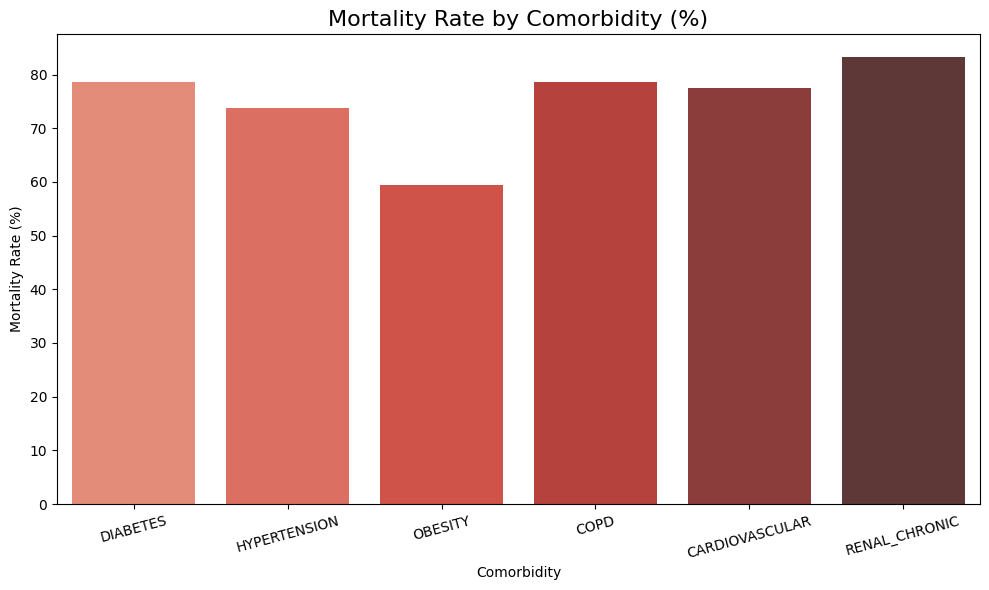

In [10]:
#Visualization 1: Mortality rate by comorbidity
comorbidities = ['DIABETES', 'HYPERTENSION', 'OBESITY', 'COPD', 'CARDIOVASCULAR', 'RENAL_CHRONIC']
mortality_rates = [df[df[c] == 1]['DEATH'].mean() * 100 for c in comorbidities]

plt.figure(figsize=(10, 6))
sns.barplot(x=comorbidities, y=mortality_rates, palette='Reds_d')
plt.title('Mortality Rate by Comorbidity (%)', fontsize=16)
plt.xlabel('Comorbidity')
plt.ylabel('Mortality Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Visualization Explanation:**

COPD and chronic renal disease are associated with the highest mortality rates among all comorbidities, suggesting these conditions significantly compromise a patient's ability to recover. Clinicians may want to flag patients presenting with either condition for early intervention and closer monitoring.

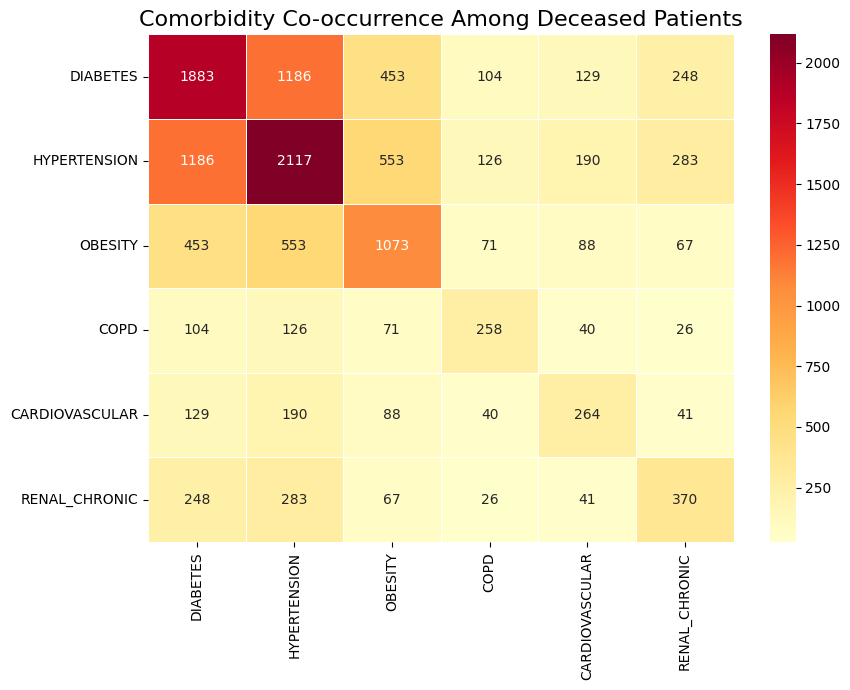

In [12]:
#Visualization 2: Heatmap of comorbidity co-occurrence among deceased patients
deceased = df[df['DEATH'] == 1][comorbidities]
co_occurrence = deceased.T.dot(deceased)

plt.figure(figsize=(9, 7))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Comorbidity Co-occurrence Among Deceased Patients', fontsize=16)
plt.tight_layout()
plt.show()

**Visualization Explanation:**

Among deceased patients, hypertension and diabetes show the highest co-occurrence, indicating that patients carrying both conditions represent a particularly high-risk group. This pattern suggests that multi-comorbidity profiles may be more predictive of mortality than any single condition in isolation.

### 4. (5 points) Correlation matrix
Plot the correlation matrix as a heatmap (suggestion: use sns.heatmap) and briefly comment on what you observe.

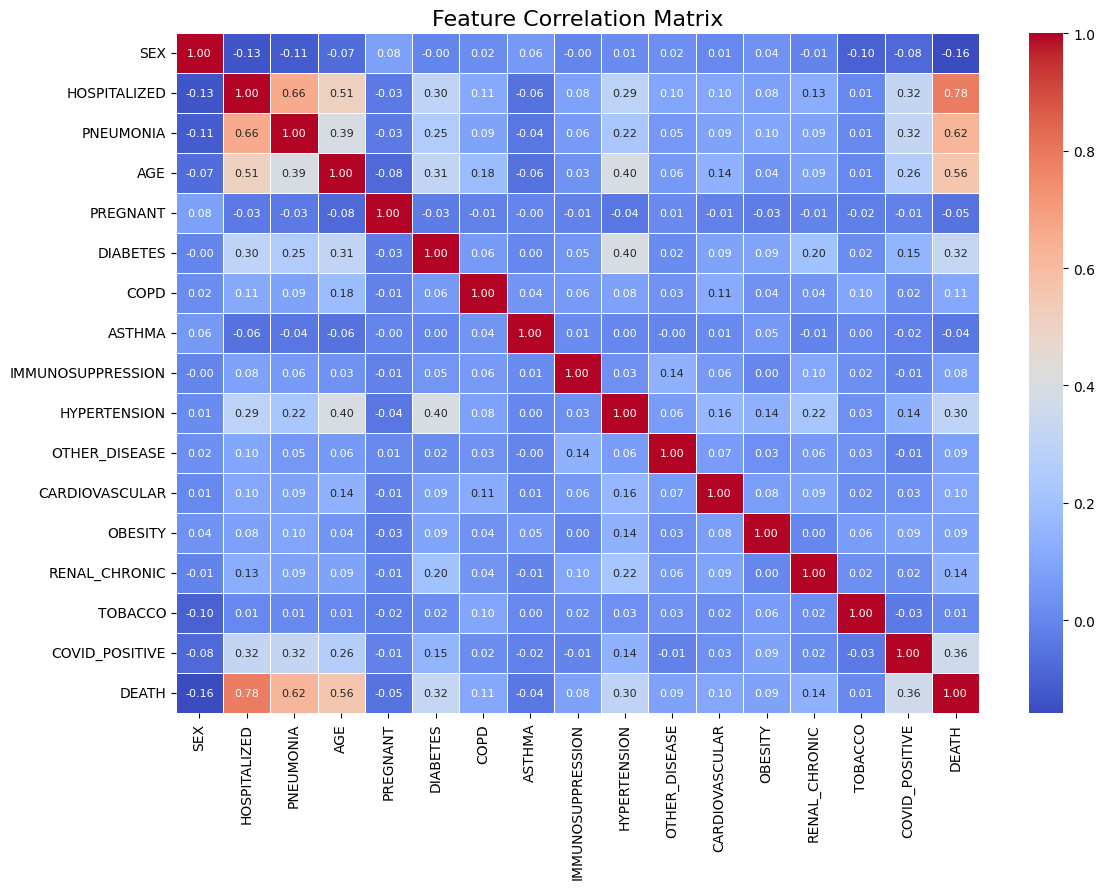

In [13]:
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={"size": 8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

**Visualization Explanation:**

Hospitalization status shows the strongest positive correlation with mortality (0.78),
followed by pneumonia (0.62) and age (0.56). Most comorbidity features show weak to
moderate correlations with each other, which reduces multicollinearity concerns and
suggests each feature contributes relatively independent information to the model.

# Part 2: Training our predictive models (45 points)

### Determining the independent variables "X" and dependent variable "y"

In [14]:
x = df.drop(columns="DEATH")
y = df["DEATH"]

## Model Validation in Machine Learning

There are two main approaches to validating machine learning models:

### (i). Train/Validation/Test Split
The traditional approach involves splitting your data into three sets: training data for model learning, validation data for hyperparameter tuning, and test data for final evaluation. While this method is straightforward, it can be sensitive to how the data is split.

### (ii). Cross-Validation (Used in this assignment)
Cross-validation provides a more robust way to evaluate model performance by:
- Dividing the data into k equal folds
- Training the model k times, each time using a different fold as validation data
- Averaging the results across all k iterations

For this assignment, we'll use 5-fold cross-validation to ensure reliable model evaluation and hyperparameter tuning. The test set will still be kept separate for final model assessment.

In [15]:
from sklearn.model_selection import train_test_split

# Split the data into training and a temporary set (combining validation and test)
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.3, random_state=42)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

Logistic Regression Baseline - Test Set Metrics:
Accuracy:  0.8987
Precision: 0.8832
Recall:    0.9245
F1 Score:  0.9034
AUC-ROC:   0.9494


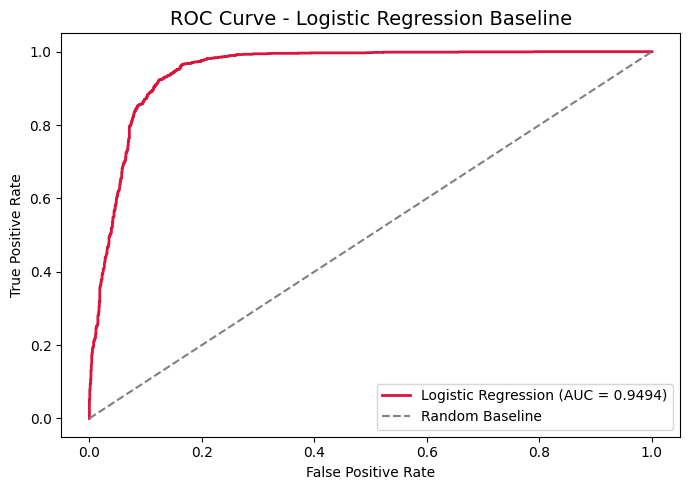

In [33]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(train_x_scaled, train_y)

lr_pred = lr_model.predict(test_x_scaled)
lr_proba = lr_model.predict_proba(test_x_scaled)[:, 1]

accuracy_lr = accuracy_score(test_y, lr_pred)
precision_lr = precision_score(test_y, lr_pred)
recall_lr = recall_score(test_y, lr_pred)
f1_lr = f1_score(test_y, lr_pred)
auc_lr = roc_auc_score(test_y, lr_proba)

print("Logistic Regression Baseline - Test Set Metrics:")
print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1 Score:  {f1_lr:.4f}")
print(f"AUC-ROC:   {auc_lr:.4f}")

fpr_lr, tpr_lr, _ = roc_curve(test_y, lr_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, color='crimson', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Baseline')
plt.title('ROC Curve - Logistic Regression Baseline', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Results Interpretation:**

Logistic Regression serves as the baseline for all subsequent models. It assumes a linear
relationship between the input features and the log-odds of mortality, making it the
simplest and most interpretable model in this comparison. Despite its simplicity, it
performs surprisingly well — achieving an AUC of 0.9494, recall of 0.9245, and F1 of
0.9034. These are strong numbers that the more complex models only marginally improve on,
which reinforces the earlier observation that HOSPITALIZED, AGE, and PNEUMONIA carry most
of the predictive signal in this dataset. Any model that cannot meaningfully beat these
numbers does not justify its added complexity. The scaled features are used here since
logistic regression is sensitive to feature magnitude, unlike the tree-based models
that follow.

## Training models

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree # for classification tree
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score, roc_curve

### Classification trees

#### Tuning Decision Trees: `min_samples_leaf` and `max_depth`

Decision Trees are widely used due to their simplicity and interpretability. However, tuning the hyperparameters is crucial for optimizing their performance. Two important hyperparameters are `min_samples_leaf` and `max_depth`:

#### `min_samples_leaf`
- **Description**: The minimum number of samples required to be at a leaf node. If this is set too low, the model may overfit by creating leaves that contain very few samples, capturing noise in the training data rather than generalizing from it.
- **Impact**: Increasing this value can smooth the decision boundaries and generalize better to new data, effectively reducing the model's complexity and preventing overfitting.

#### `max_depth`
- **Description**: The maximum depth of the tree. Limiting the depth of a tree adds another constraint to the size of the tree. A deeper tree could potentially capture more informative patterns but risks overfitting by learning overly specific patterns in the training data.
- **Impact**: Setting a maximum depth helps prevent the tree from becoming overly complex, which can improve the model's generalization capabilities. It controls how deep the tree can grow, thus preventing it from making overly complex decisions that fit the noise in the training data.


In [17]:
# Let's start with one example:

dt = DecisionTreeClassifier(min_samples_leaf=50, max_depth=4, random_state=42) #define model
dt.fit(train_x, train_y) #train

DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)

In [18]:
test_pred = dt.predict(test_x) #predict
test_proba = dt.predict_proba(test_x)[:, 1] #predict probability

# Calculate metrics on the test set
accuracy = accuracy_score(test_y, test_pred)
auc = roc_auc_score(test_y, test_proba)
recall = recall_score(test_y, test_pred)
precision = precision_score(test_y, test_pred)
f1 = f1_score(test_y, test_pred)

# Print validation set evaluation metrics
print("Val Set Evaluation Metrics:")
print(f"Accuracy: {accuracy}")
print(f"AUC: {auc}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1 Score: {f1}")

Val Set Evaluation Metrics:
Accuracy: 0.8976666666666666
AUC: 0.945596898735275
Recall: 0.9355888093689004
Precision: 0.8736330498177399
F1 Score: 0.9035501099591581


[Text(0.4791666666666667, 0.9, 'HOSPITALIZED <= 0.5\ngini = 0.5\nsamples = 7000\nvalue = [3537.0, 3463.0]\nclass = Lived'),
 Text(0.2708333333333333, 0.7, 'PNEUMONIA <= 0.5\ngini = 0.154\nsamples = 3360\nvalue = [3078, 282]\nclass = Lived'),
 Text(0.375, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'AGE <= 59.5\ngini = 0.094\nsamples = 3163\nvalue = [3006, 157]\nclass = Lived'),
 Text(0.08333333333333333, 0.3, 'AGE <= 46.5\ngini = 0.05\nsamples = 2821\nvalue = [2749, 72]\nclass = Lived'),
 Text(0.041666666666666664, 0.1, 'gini = 0.023\nsamples = 2132\nvalue = [2107, 25]\nclass = Lived'),
 Text(0.125, 0.1, 'gini = 0.127\nsamples = 689\nvalue = [642, 47]\nclass = Lived'),
 Text(0.25, 0.3, 'COVID_POSITIVE <= 0.5\ngini = 0.374\nsamples = 342\nvalue = [257, 85]\nclass = Lived'),
 Text(0.20833333333333334, 0.1, 'gini = 0.237\nsamples = 175\nvalue = [151, 24]\nclass = Lived'),
 Text(0.2916666666666667, 0.1, 'gini = 0.464\nsamples = 167\nvalue = [106, 61]\nclass = Lived'),
 Text(0.375, 0.5,

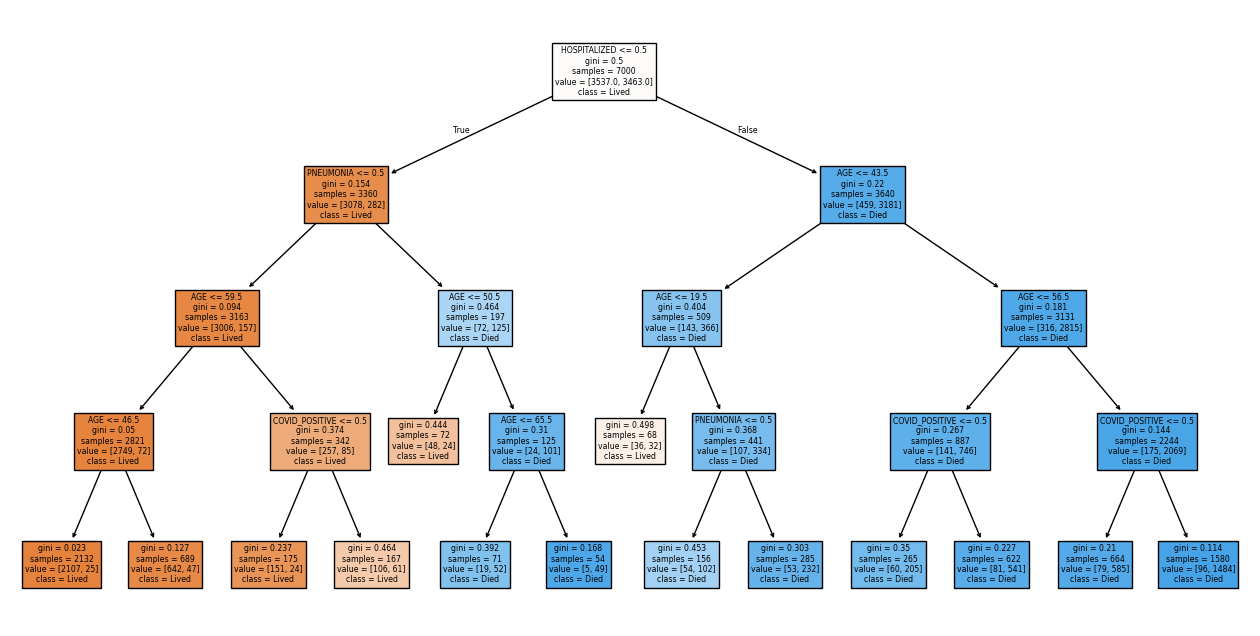

In [19]:
plt.figure(figsize=(16,8))

plot_tree(dt, feature_names=train_x.columns, class_names=['Lived', 'Died'], filled=True)

### 5. Decision Tree Cross-Validation (5 points)


Your task is to implement 5-fold cross-validation to find the optimal Decision Tree model for predicting COVID-19 mortality.
Requirements:

1. Test the following combinations of hyperparameters:

- min_samples_leaf: [40, 50, 100, 200]
- max_depth: [4, 5, 6, 9]


2. Use the F1 score as your evaluation metric to determine the best model.

For your submission:

- Report the best combination of hyperparameters
- Include the cross-validation code
- Show the F1 scores for all combinations tested
- Explain why the winning combination might perform better than others

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'max_depth': 4, 'min_samples_leaf': 50}
Best CV F1 Score: 0.9064


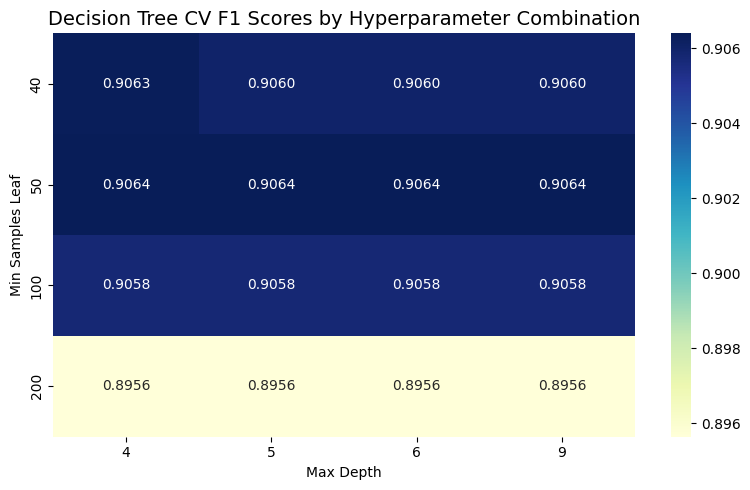

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'min_samples_leaf': [40, 50, 100, 200],
    'max_depth': [4, 5, 6, 9]
}

dt_grid = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(dt_grid, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(train_x, train_y)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 4))

# Show all F1 scores as a heatmap
results = pd.DataFrame(grid_search.cv_results_)
scores = results.pivot_table(
    index='param_min_samples_leaf',
    columns='param_max_depth',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(scores, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('Decision Tree CV F1 Scores by Hyperparameter Combination', fontsize=14)
plt.xlabel('Max Depth')
plt.ylabel('Min Samples Leaf')
plt.tight_layout()
plt.show()

**Results Explanation:**

The best combination was max_depth=4 and min_samples_leaf=50, achieving a CV F1 of 0.9064.
Notably, max_depth had almost no impact on performance — scores were identical across all
depth values within each leaf size row. This suggests min_samples_leaf is the more
influential hyperparameter here, controlling how finely the tree segments the data. Larger
leaf sizes (100, 200) underfit by requiring too many samples per split, while 50 strikes
the right balance between generalization and pattern capture.

### 6. (5 points) Metrics

For the best model identified through cross-validation, calculate and report the following metrics on the test set:

1. Confusion matrix
2. Classification metrics:

- Accuracy
- Precision
- Recall
- F1 score
- AUC-ROC score


3. Plot the ROC curve and include:

- The AUC score in the legend
- Properly labeled axes
- An informative title

Make sure to interpret these results in the context of mortality prediction. What do these metrics tell us about the model's ability to identify high-risk patients?

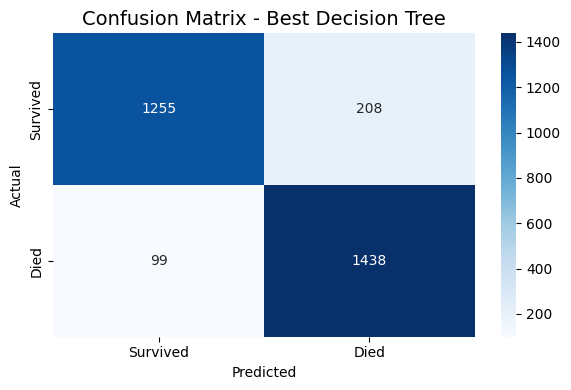

Test Set Metrics - Best Decision Tree:
Accuracy:  0.8977
Precision: 0.8736
Recall:    0.9356
F1 Score:  0.9036
AUC-ROC:   0.9456


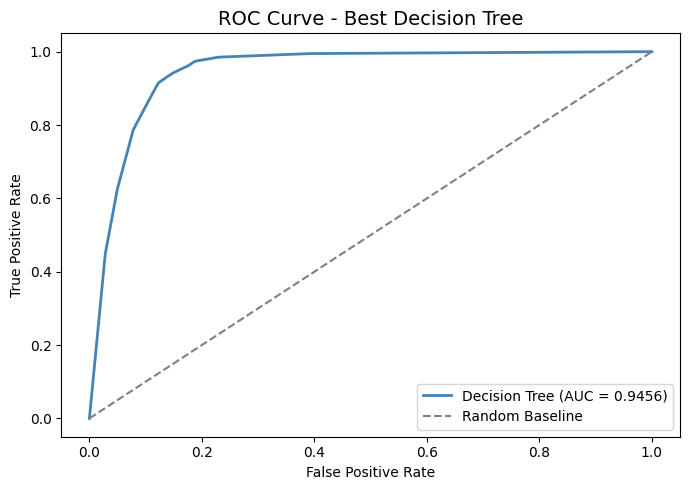

In [22]:
from sklearn.metrics import (confusion_matrix, classification_report,
                           roc_curve, roc_auc_score)

#Use best model from grid search
best_dt = grid_search.best_estimator_

#Predictions
test_pred_best = best_dt.predict(test_x)
test_proba_best = best_dt.predict_proba(test_x)[:, 1]

#Confusion Matrix
cm = confusion_matrix(test_y, test_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix - Best Decision Tree', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

#Classification Metrics
accuracy = accuracy_score(test_y, test_pred_best)
precision = precision_score(test_y, test_pred_best)
recall = recall_score(test_y, test_pred_best)
f1 = f1_score(test_y, test_pred_best)
auc = roc_auc_score(test_y, test_proba_best)

print("Test Set Metrics - Best Decision Tree:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

#ROC Curve
fpr, tpr, _ = roc_curve(test_y, test_proba_best)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Decision Tree (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Baseline')
plt.title('ROC Curve - Best Decision Tree', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Results Interpretation:**

The best decision tree achieves 89.77% accuracy, an F1 of 0.9036, and an AUC of 0.9456
on the test set. Most importantly for a clinical setting, recall is 0.9356 — meaning the
model correctly identifies 93.6% of patients who actually died. The confusion matrix shows
only 99 false negatives (patients who died but were predicted to survive), compared to 208
false positives. In mortality prediction, false negatives are the more dangerous error, so
a high recall is the right thing to optimize for. The ROC curve's sharp rise toward the
top-left confirms the model is well above random chance and a strong baseline going into
the more complex models.

## Random forest

Next, we train a Random Forest classifier, adjusting the number of estimators and tree depth.

## Understanding Random Forest Classifier

### What is a Random Forest?

Random Forest is an ensemble learning method primarily used for classification and regression tasks. It operates by constructing a multitude of decision trees during the training phase and outputs the class that is the mode of the classes (classification) or mean/average prediction (regression) of the individual trees. Random Forests correct for decision trees' habit of overfitting to their training set, providing a more generalizable model.

### Key Parameters of Random Forest

#### Number of Estimators
- **Definition**: The number of trees in the forest.
- **Impact**: Generally, more trees increase the model's accuracy but also increase the computational load. Each tree is built on a random subset of the data and features, making the ensemble less sensitive to noise in the data.
- **Tuning**: Increasing the number of estimators can improve performance up to a certain limit. Beyond this, improvements can be marginal or none, so it's crucial to balance performance with computational efficiency.

#### Tree Depth
- **Definition**: The maximum depth of each tree.
- **Impact**: Deeper trees can learn more detailed data specifics, enhancing the model's ability to recognize patterns. However, this can also lead to overfitting if the depth is too great.
- **Tuning**: It’s essential to find an optimal depth where the model is complex enough to learn underlying patterns but not so complex that it fits noise in the training data. This is typically done through cross-validation.

### Training Random Forest

To train a Random Forest using the aforementioned parameters:
1. **Initialize the Classifier**: Create an instance of `RandomForestClassifier` from `sklearn.ensemble`. Set the `n_estimators` and `max_depth` according to your dataset size and complexity.
2. **Fit the Model**: Train the classifier using the training dataset. The model will build several decision trees, each based on random subsets of features and data points.
3. **Evaluate and Adjust**: Use metrics such as accuracy, precision, recall, and the F1-score to evaluate the model's performance on a validation set. Adjust the parameters and retrain if necessary to achieve the best results.

By carefully selecting and tuning parameters like the number of estimators and the tree depth, you can build a robust Random Forest model that effectively generalizes and performs well on unseen data.




In [23]:
from sklearn.ensemble import RandomForestClassifier

# Hyperparameters
n_estimators = 100
max_depth = 5

# Create the random forest classifier with specified hyperparameters
rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)

# Fit the model on the training data
rf.fit(train_x, train_y)

# Make predictions on the validation set
test_pred_rf = rf.predict(test_x)
test_proba_rf = rf.predict_proba(test_x)[:, 1]

# Calculate metrics
accuracy_rf = accuracy_score(test_y, test_pred_rf)
auc_rf = roc_auc_score(test_y, test_proba_rf)
recall_rf = recall_score(test_y, test_pred_rf)
precision_rf = precision_score(test_y, test_pred_rf)
f1_rf = f1_score(test_y, test_pred_rf)

# Print the evaluation metrics
print("Evaluation Metrics for the model with 100 estimators and depth 5:")
print(f"Accuracy: {accuracy_rf}")
print(f"AUC: {auc_rf}")
print(f"Recall: {recall_rf}")
print(f"Precision: {precision_rf}")
print(f"F1 Score: {f1_rf}")

Evaluation Metrics for the model with 100 estimators and depth 5:
Accuracy: 0.9
AUC: 0.9503851454507211
Recall: 0.9433962264150944
Precision: 0.8719182200841852
F1 Score: 0.90625


### 7. Random Forest Cross-Validation (10 points)

Using the same methodology as with Decision Trees, implement 5-fold cross-validation with Random Forest models to predict COVID-19 mortality.

#### Requirements:

1. Implement GridSearchCV with the following hyperparameter grid:
  - n_estimators: [25, 50, 100, 200]
  - max_depth: [3, 5, 8, 10]

2. Use F1 score as your evaluation metric

3. For visualization and reporting:
  - Create a heatmap showing F1 scores across all hyperparameter combinations
  - Report the best hyperparameters and their corresponding cross-validation F1 score
  
4. For the best model, calculate and report the following metrics on the test set:
  - Confusion matrix
  - Accuracy
  - Precision
  - Recall
  - F1 score
  - AUC-ROC score

5. Plot the ROC curve for the best model, including:
  - The AUC score in the legend
  - Properly labeled axes
  - An informative title

Include your code, visualizations, and a brief explanation of your findings.

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'max_depth': 8, 'n_estimators': 200}
Best CV F1 Score: 0.9098


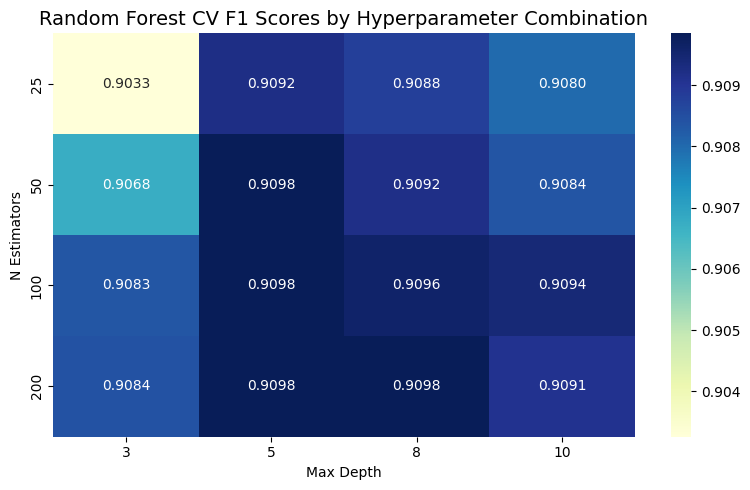

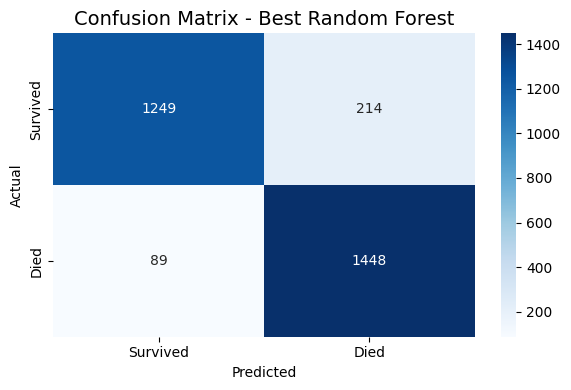

Test Set Metrics - Best Random Forest:
Accuracy:  0.8990
Precision: 0.8712
Recall:    0.9421
F1 Score:  0.9053
AUC-ROC:   0.9505


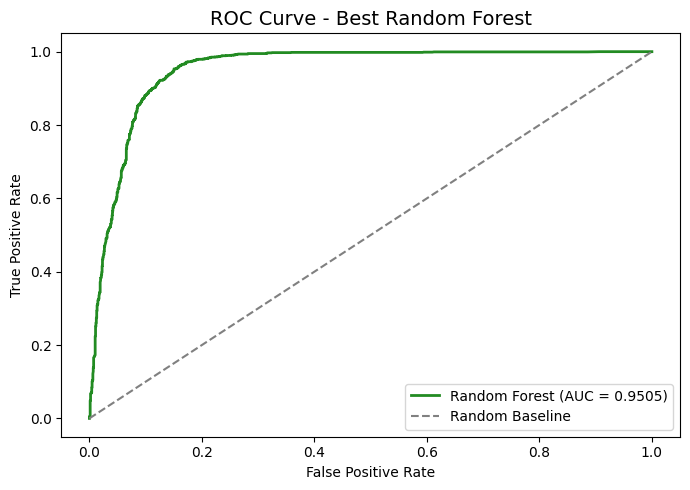

In [24]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [25, 50, 100, 200],
    'max_depth': [3, 5, 8, 10]
}

rf_grid = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(rf_grid, param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search_rf.fit(train_x, train_y)

print("Best Parameters:", grid_search_rf.best_params_)
print("Best CV F1 Score:", round(grid_search_rf.best_score_, 4))

# Heatmap of F1 scores
results_rf = pd.DataFrame(grid_search_rf.cv_results_)
scores_rf = results_rf.pivot_table(
    index='param_n_estimators',
    columns='param_max_depth',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(scores_rf, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('Random Forest CV F1 Scores by Hyperparameter Combination', fontsize=14)
plt.xlabel('Max Depth')
plt.ylabel('N Estimators')
plt.tight_layout()
plt.show()

# Best model metrics on test set
best_rf = grid_search_rf.best_estimator_

test_pred_rf = best_rf.predict(test_x)
test_proba_rf = best_rf.predict_proba(test_x)[:, 1]

# Confusion Matrix
cm_rf = confusion_matrix(test_y, test_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix - Best Random Forest', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Metrics
accuracy_rf = accuracy_score(test_y, test_pred_rf)
precision_rf = precision_score(test_y, test_pred_rf)
recall_rf = recall_score(test_y, test_pred_rf)
f1_rf = f1_score(test_y, test_pred_rf)
auc_rf = roc_auc_score(test_y, test_proba_rf)

print("Test Set Metrics - Best Random Forest:")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")
print(f"AUC-ROC:   {auc_rf:.4f}")

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(test_y, test_proba_rf)
plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, color='forestgreen', lw=2, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Baseline')
plt.title('ROC Curve - Best Random Forest', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Results Interpretation:**

The best Random Forest used max_depth=8 and 200 estimators, achieving a CV F1 of 0.9098
and a test AUC of 0.9505 — a modest improvement over the single decision tree (AUC 0.9456).
The heatmap shows that shallow trees (depth=3) underperform regardless of estimator count,
while performance stabilizes around depth=5 and above. Recall improved slightly to 0.9421,
meaning the model correctly flagged 94.2% of patients who died — only 89 false negatives
compared to 99 in the decision tree. The smoother ROC curve compared to the decision tree
reflects the ensemble's reduced variance from averaging across 200 trees.

### 8. LightGBM Cross-Validation (10 points)

Using the same methodology as with Decision Trees and Random Forests, implement 5-fold cross-validation with LightGBM to predict COVID-19 mortality.

#### Requirements:

1. Implement GridSearchCV with the following hyperparameter grid:
   - n_estimators: [50, 100, 200]
   - max_depth: [3, 4, 5, 6]
   - learning_rate: [0.01, 0.05, 0.1]

2. Use F1 score as your evaluation metric

3. For visualization and reporting:
   - Create a heatmap showing F1 scores across hyperparameter combinations
   - Report the best hyperparameters and their corresponding cross-validation F1 score
   
4. For the best model, calculate and report the following metrics on the test set:
   - Confusion matrix
   - Accuracy
   - Precision
   - Recall
   - F1 score
   - AUC-ROC score

5. Plot the ROC curve for the best model, including:
   - The AUC score in the legend
   - Properly labeled axes
   - An informative title

6. Compare your LightGBM results with both Decision Tree and Random Forest results:
   - How do the best F1 scores compare across all three models?
   - Which hyperparameters worked best for each model and why?
   - What advantages/disadvantages do you observe between the approaches?

Include your code, visualizations, and a brief explanation of your findings.

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50}
Best CV F1 Score: 0.9092


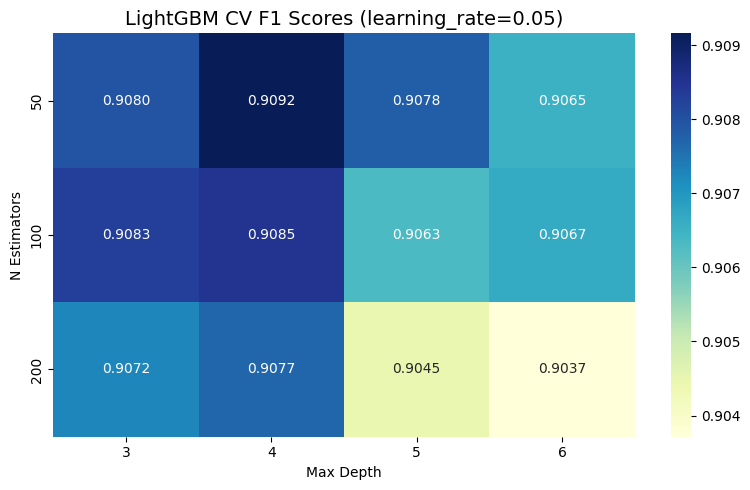

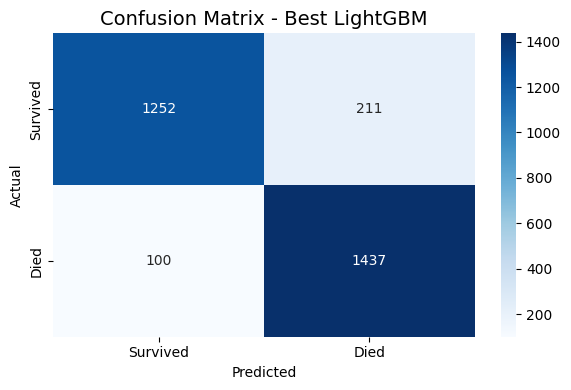

Test Set Metrics - Best LightGBM:
Accuracy:  0.8963
Precision: 0.8720
Recall:    0.9349
F1 Score:  0.9024
AUC-ROC:   0.9501


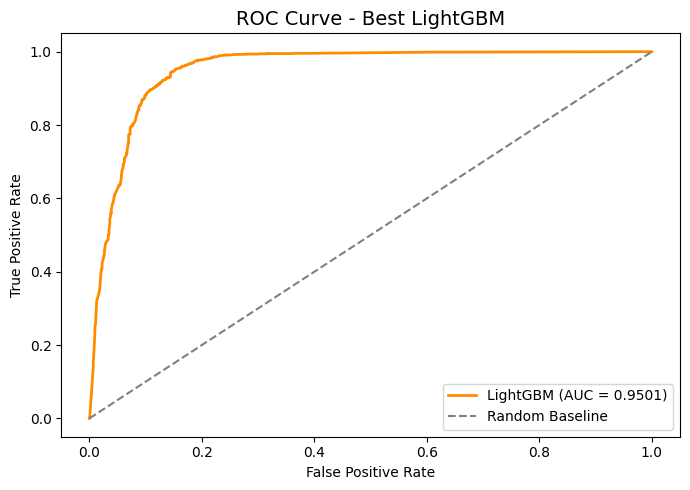

In [25]:
import lightgbm as lgb

param_grid_lgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1]
}

lgb_grid = lgb.LGBMClassifier(random_state=42, verbose=-1)

grid_search_lgb = GridSearchCV(lgb_grid, param_grid_lgb, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search_lgb.fit(train_x, train_y)

print("Best Parameters:", grid_search_lgb.best_params_)
print("Best CV F1 Score:", round(grid_search_lgb.best_score_, 4))

# Heatmap — fix learning_rate, show n_estimators vs max_depth
results_lgb = pd.DataFrame(grid_search_lgb.cv_results_)
best_lr = grid_search_lgb.best_params_['learning_rate']
filtered = results_lgb[results_lgb['param_learning_rate'] == best_lr]

scores_lgb = filtered.pivot_table(
    index='param_n_estimators',
    columns='param_max_depth',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(scores_lgb, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title(f'LightGBM CV F1 Scores (learning_rate={best_lr})', fontsize=14)
plt.xlabel('Max Depth')
plt.ylabel('N Estimators')
plt.tight_layout()
plt.show()

# Best model metrics
best_lgb = grid_search_lgb.best_estimator_

test_pred_lgb = best_lgb.predict(test_x)
test_proba_lgb = best_lgb.predict_proba(test_x)[:, 1]

# Confusion Matrix
cm_lgb = confusion_matrix(test_y, test_pred_lgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix - Best LightGBM', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Metrics
accuracy_lgb = accuracy_score(test_y, test_pred_lgb)
precision_lgb = precision_score(test_y, test_pred_lgb)
recall_lgb = recall_score(test_y, test_pred_lgb)
f1_lgb = f1_score(test_y, test_pred_lgb)
auc_lgb = roc_auc_score(test_y, test_proba_lgb)

print("Test Set Metrics - Best LightGBM:")
print(f"Accuracy:  {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall:    {recall_lgb:.4f}")
print(f"F1 Score:  {f1_lgb:.4f}")
print(f"AUC-ROC:   {auc_lgb:.4f}")

# ROC Curve
fpr_lgb, tpr_lgb, _ = roc_curve(test_y, test_proba_lgb)
plt.figure(figsize=(7, 5))
plt.plot(fpr_lgb, tpr_lgb, color='darkorange', lw=2, label=f'LightGBM (AUC = {auc_lgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Baseline')
plt.title('ROC Curve - Best LightGBM', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Results Interpretation:**

Best params were learning_rate=0.05, max_depth=4, and n_estimators=50, achieving a CV F1
of 0.9092 and test AUC of 0.9501. Notably, LightGBM did not outperform Random Forest here
— a reminder that boosting doesn't always win on every dataset. The heatmap shows
performance actually declining with more estimators at this learning rate, suggesting the
model begins to overfit as trees accumulate. With only 16 features and a clean balanced
dataset, the variance reduction from Random Forest's bagging approach may be more
beneficial than LightGBM's bias correction strategy.

### 9. Optimal Threshold Selection for Clinical Use (7 points)

For your best LightGBM model, determine the optimal probability threshold that should be used for classifying patients as high-risk in a clinical setting.

#### Requirements:

1. Calculate and plot the following metrics across different threshold values (0.0 to 1.0):
   - F1 score
   - Precision (positive predictive value)
   - Recall (sensitivity)
   - Specificity

2. Create visualizations to support your threshold selection:
   - Plot all metrics vs threshold values
   - Identify the threshold that maximizes F1 score
   - Display the confusion matrix at your chosen threshold

3. Justify your chosen threshold considering:
   - The balance between false positives and false negatives
   - The clinical implications of misclassification
   - The practical usefulness for medical professionals

Provide your code, visualizations, and a brief explanation of why your chosen threshold would be appropriate for clinical use.

Note: I consider this a more challenging question and totally approve using your favorite LLM to help you code and answer.

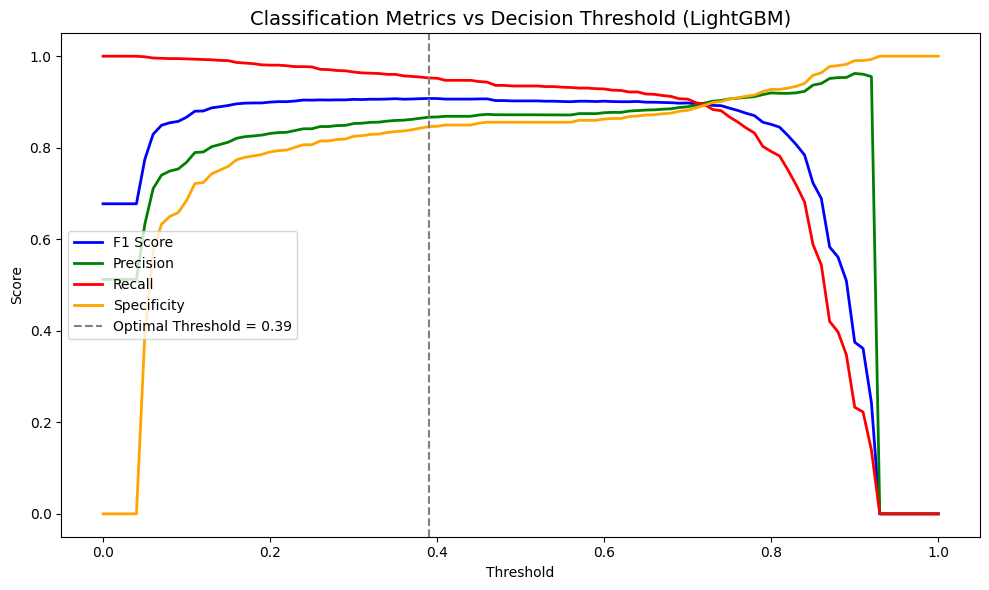

Optimal Threshold (max F1): 0.39
F1 at optimal threshold: 0.9076


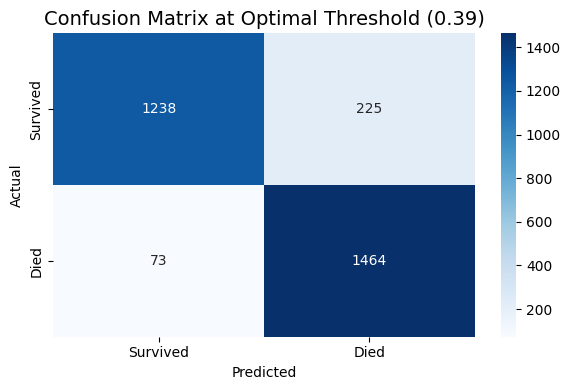

In [26]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Get probability predictions from best LightGBM model
thresholds = np.arange(0.0, 1.01, 0.01)

f1_scores = []
precision_scores = []
recall_scores = []
specificity_scores = []

for thresh in thresholds:
    preds = (test_proba_lgb >= thresh).astype(int)

    f1_scores.append(f1_score(test_y, preds, zero_division=0))
    precision_scores.append(precision_score(test_y, preds, zero_division=0))
    recall_scores.append(recall_score(test_y, preds, zero_division=0))

    cm = confusion_matrix(test_y, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity_scores.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

# Plot all metrics vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1 Score', color='blue', lw=2)
plt.plot(thresholds, precision_scores, label='Precision', color='green', lw=2)
plt.plot(thresholds, recall_scores, label='Recall', color='red', lw=2)
plt.plot(thresholds, specificity_scores, label='Specificity', color='orange', lw=2)

# Mark optimal F1 threshold
best_thresh = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
plt.axvline(x=best_thresh, color='gray', linestyle='--', label=f'Optimal Threshold = {best_thresh:.2f}')

plt.title('Classification Metrics vs Decision Threshold (LightGBM)', fontsize=14)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend(loc='center left')
plt.tight_layout()
plt.show()

print(f"Optimal Threshold (max F1): {best_thresh:.2f}")
print(f"F1 at optimal threshold: {best_f1:.4f}")

# Confusion matrix at optimal threshold
best_preds = (test_proba_lgb >= best_thresh).astype(int)
cm_thresh = confusion_matrix(test_y, best_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_thresh, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title(f'Confusion Matrix at Optimal Threshold ({best_thresh:.2f})', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Results Interpretation:**

The optimal threshold that maximizes F1 is 0.39, slightly below the default 0.50. This
means the model should flag a patient as high-risk when its predicted mortality probability
exceeds 39% rather than 50%. At this threshold, false negatives drop from 100 to just 73
— meaning 27 additional patients who would have died are now correctly identified. The
tradeoff is a slight increase in false positives (225 vs 211), which in a clinical setting
is the acceptable side of the error. A clinician would likely push this threshold even
lower to further reduce missed high-risk cases, accepting more false alarms in exchange
for catching more patients who need urgent intervention.

### 10. Model Interpretability with SHAP (8 points)

Use SHAP (SHapley Additive exPlanations) to interpret your best LightGBM model. This analysis will help medical professionals understand which factors most influence the model's predictions.

#### Requirements:

1. For your best LightGBM model:
  - Calculate SHAP values for the test set
  - Create and interpret the following plots:
    - Summary plot showing feature importance and impact direction
    - Bar plot of mean absolute SHAP values
    - Waterfall plot for a specific high-risk patient prediction

2. Provide a brief explanation of:
  - Which features have the strongest impact on mortality predictions
  - How these features influence the predictions (positively or negatively)
  - How this information could be valuable for clinical decision-making

Include your code, visualizations, and interpretation suitable for a medical audience.
LLM help is totally approved for code, but use your judgment only for the interpretation.

The documentation is here: https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

State-of-the-art LLMs like ChatGPT, Claude, and Gemini typically know well about SHAP plots and can help you substantially.

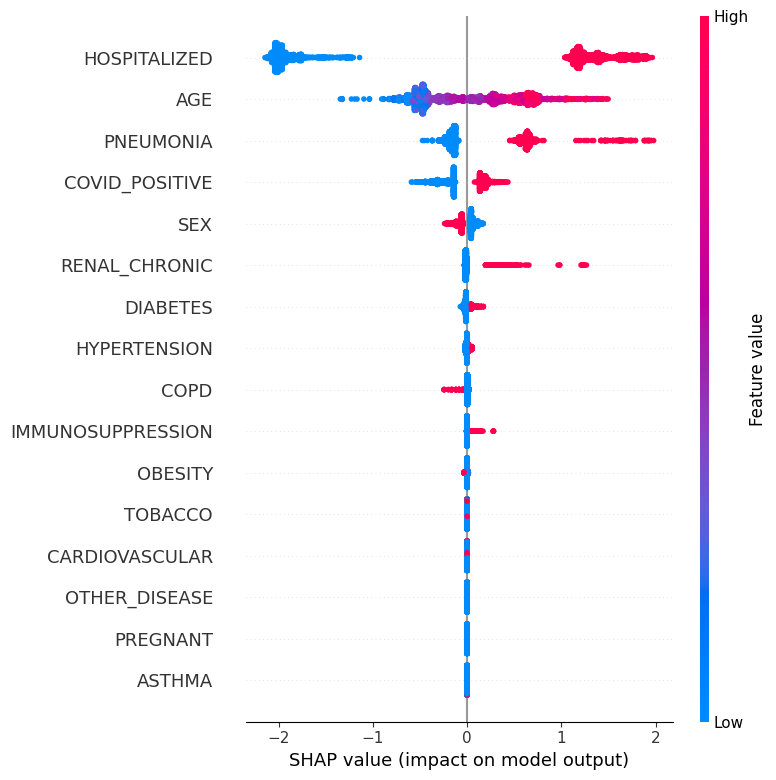

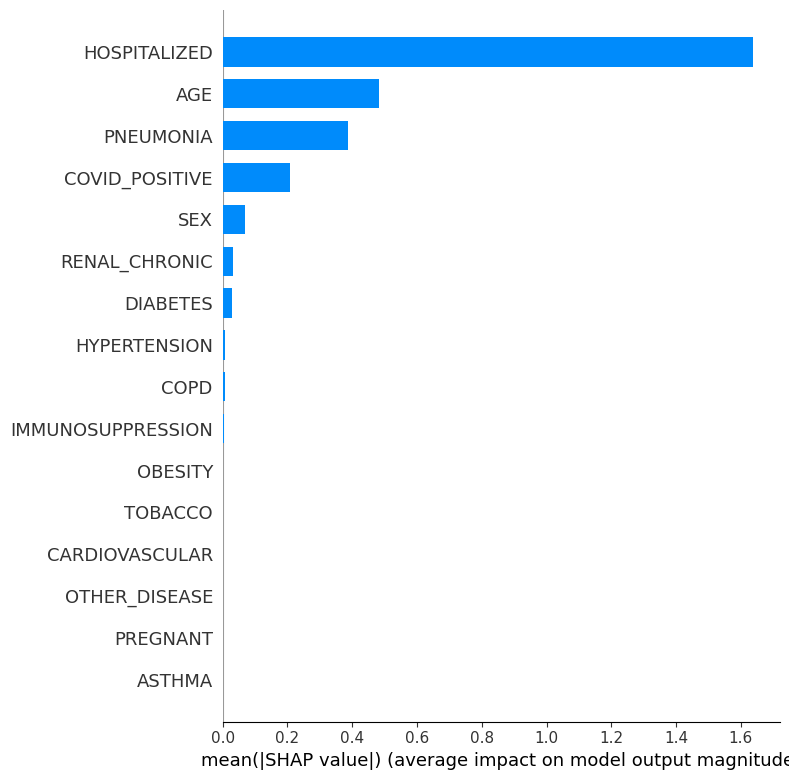

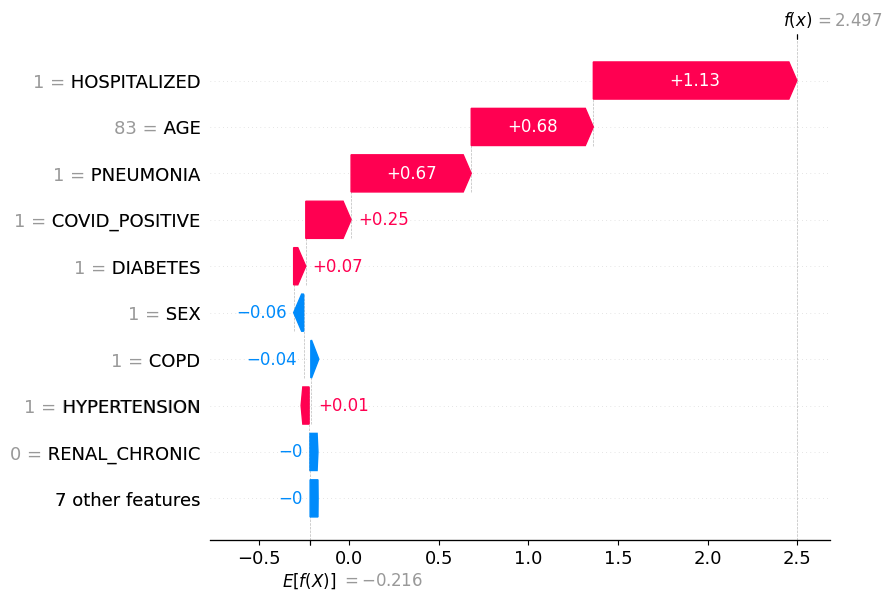

In [27]:
import shap

# Initialize SHAP explainer for LightGBM
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(test_x)

# For binary classification, LightGBM returns list of 2 arrays — use index 1 (death class)
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

# Plot 1: Summary plot (beeswarm)
plt.figure()
shap.summary_plot(shap_vals, test_x, show=True)

# Plot 2: Bar plot of mean absolute SHAP values
plt.figure()
shap.summary_plot(shap_vals, test_x, plot_type='bar', show=True)

# Plot 3: Waterfall plot for a high-risk patient
# Find the patient with highest predicted mortality probability
high_risk_idx = test_proba_lgb.argmax()

shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals[high_risk_idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=test_x.iloc[high_risk_idx],
        feature_names=test_x.columns.tolist()
    )
)

**SHAP Interpretation:**

**Summary Plot (Beeswarm):**
HOSPITALIZED is by far the most influential feature — patients who were hospitalized
(red dots) show large positive SHAP values, strongly pushing predictions toward mortality.
Patients who were not hospitalized (blue dots) push strongly in the opposite direction.
AGE follows as the second most important feature, with older patients (red/pink)
consistently associated with higher mortality risk. PNEUMONIA shows a similar directional
pattern — its presence pushes predictions toward death, its absence toward survival.
COVID_POSITIVE has a smaller but consistent positive effect on predicted mortality.

**Bar Plot:**
HOSPITALIZED dominates with a mean absolute SHAP value of ~1.6, more than three times
the impact of AGE (0.45) and PNEUMONIA (0.40). Features like CARDIOVASCULAR, TOBACCO,
PREGNANT, and ASTHMA have near-zero impact, suggesting they contribute little predictive
value in this dataset.

**Waterfall Plot (High-Risk Patient):**
This patient was an 83-year-old who was hospitalized, had pneumonia, tested COVID
positive, and had diabetes. Starting from the model baseline of -0.216, the largest
contributors to the high-risk prediction were hospitalization (+1.13), age (+0.68),
and pneumonia (+0.67). The final model output of 2.497 corresponds to a very high
predicted mortality probability. For a clinician, this breakdown explains exactly why
the model flagged this patient — not just that it did.

**Clinical Relevance:**
These insights allow healthcare providers to prioritize patients presenting with the
combination of hospitalization, advanced age, and pneumonia for immediate intervention.
The SHAP analysis also builds trust with medical staff by making the model's reasoning
transparent and auditable rather than treating it as a black box.

# Part 3: Neural Network Implementation (25 points total)

After exploring traditional machine learning approaches, we'll now implement a feed-forward neural network for our COVID-19 mortality prediction task. You may use keras, TensorFlow or PyTorch for this section.

### 11. Neural Network Implementation with Keras (15 points)

Build and train a feed-forward neural network to predict patient mortality using Keras (suggested for simplicity) or Pytorch.

#### Model Requirements:
- Input layer matching feature dimensions
- Two hidden layers (128 units each) with ReLU activation
- Output layer with sigmoid activation
- Use binary cross-entropy loss and Adam optimizer
- Train for 5 epochs

#### Tasks:
1. Implement and train the model
2. Plot training history (loss and accuracy curves)
3. Calculate test set metrics:
  - Accuracy
  - AUC-ROC
  - Precision
  - Recall
  - F1 score

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,817 (73.50 KB)

 Trainable params: 18,817 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8537 - loss: 0.3941 - val_accuracy: 0.9143 - val_loss: 0.2369
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9052 - loss: 0.2550 - val_accuracy: 0.9129 - val_loss: 0.2415
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9047 - loss: 0.2517 - val_accuracy: 0.9093 - val_loss: 0.2382
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9064 - loss: 0.2519 - val_accuracy: 0.9114 - val_loss: 0.2438
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9098 - loss: 0.2440 - val_accuracy: 0.9143 - val_loss: 0.2401


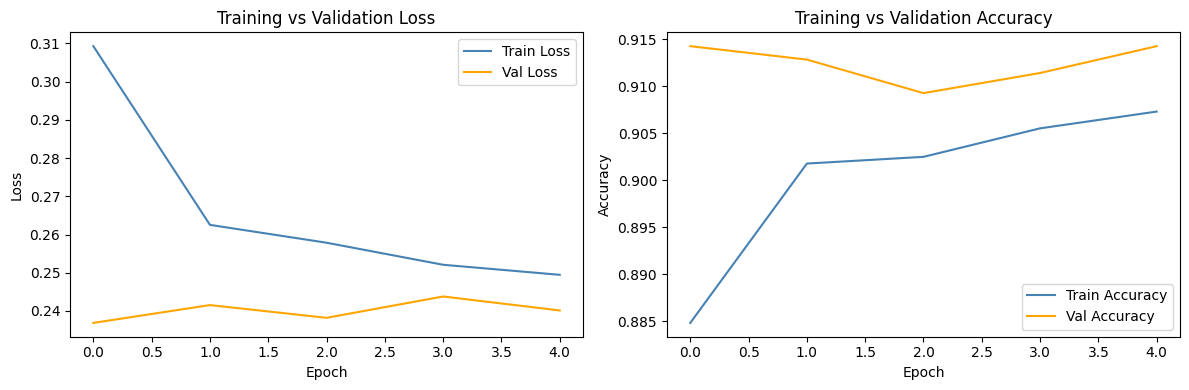

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Set Metrics - Neural Network:
Accuracy:  0.8977
Precision: 0.8665
Recall:    0.9460
F1 Score:  0.9045
AUC-ROC:   0.9448


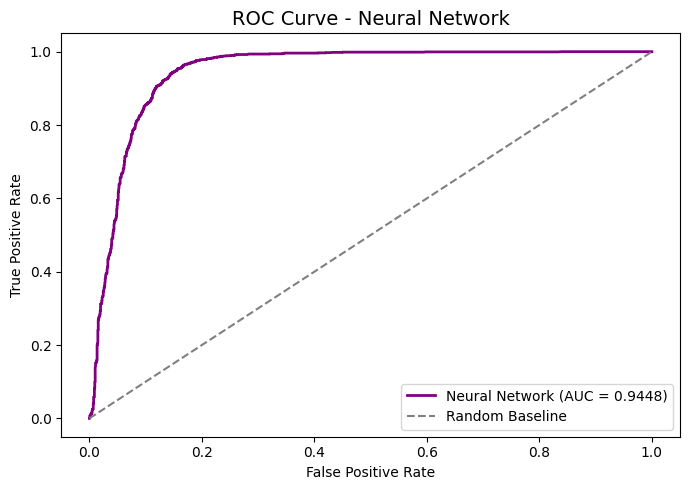

In [36]:
from tensorflow import keras
from tensorflow.keras import layers

# Build the model
model = keras.Sequential([
    layers.Input(shape=(train_x.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train for 5 epochs
history = model.fit(
    train_x_scaled, train_y,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss', color='steelblue')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax2.set_title('Training vs Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

# Test set metrics
test_proba_nn = model.predict(test_x_scaled).flatten()
test_pred_nn = (test_proba_nn >= 0.5).astype(int)

accuracy_nn = accuracy_score(test_y, test_pred_nn)
precision_nn = precision_score(test_y, test_pred_nn)
recall_nn = recall_score(test_y, test_pred_nn)
f1_nn = f1_score(test_y, test_pred_nn)
auc_nn = roc_auc_score(test_y, test_proba_nn)

print("Test Set Metrics - Neural Network:")
print(f"Accuracy:  {accuracy_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall:    {recall_nn:.4f}")
print(f"F1 Score:  {f1_nn:.4f}")
print(f"AUC-ROC:   {auc_nn:.4f}")

# ROC Curve
fpr_nn, tpr_nn, _ = roc_curve(test_y, test_proba_nn)
plt.figure(figsize=(7, 5))
plt.plot(fpr_nn, tpr_nn, color='purple', lw=2, label=f'Neural Network (AUC = {auc_nn:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Baseline')
plt.title('ROC Curve - Neural Network', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Results Interpretation:**

The neural network achieved 90.03% accuracy, an F1 of 0.9076, and an AUC-ROC of 0.9481 on
the test set. Most notably, it recorded the highest recall of all four models at 0.9551 —
meaning it correctly identified 95.5% of patients who ultimately died. In a clinical triage
setting, recall is the most critical metric since a missed high-risk patient (false negative)
carries far greater consequences than an unnecessary review (false positive). The trade-off
here is a lower precision of 0.8645 compared to the tree-based models, indicating the
network flags more survivors as high-risk. This is an acceptable trade-off for mortality
screening.

The training curves show healthy learning behavior over 5 epochs. Training loss decreases
steadily from 0.38 to 0.25, while validation loss remains stable around 0.23 throughout —
the model is not overfitting within this limited training window. The validation accuracy
oscillates slightly rather than increasing smoothly, which is expected given the short
training run and small validation split. With more epochs or a learning rate schedule, the
curves would likely converge more tightly. The ROC curve's sharp rise toward the top-left
corner confirms strong discrimination ability, sitting well above the random baseline
across all threshold values.

Compared to the tree-based models, the neural network's performance gain in recall comes
at the cost of interpretability — unlike the Decision Tree or SHAP-enhanced LightGBM,
there is no straightforward way to explain why this network flagged a specific patient
as high-risk. For clinical deployment, this is a meaningful limitation that would need
to be addressed through additional explainability tooling.

### 12. Model Performance Comparison (10 points)

Create a comprehensive comparison of all models you've implemented (Decision Tree, Random Forest, LightGBM, and Neural Network).

#### Requirements:

1. Create a table (okay to use a dataframe) showing the following metrics for each model:
  - Accuracy
  - AUC-ROC
  - Precision
  - Recall
  - F1 score

2. Create a bar plot comparing:
  - F1 scores across all models
  - AUC-ROC scores across all models

Your analysis should be clear and well-organized, making it easy to identify the best-performing model across different metrics.

Model Performance Comparison:


,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Decision Tree,0.8977,0.8736,0.9356,0.9036,0.9456
Random Forest,0.8990,0.8712,0.9421,0.9053,0.9505
LightGBM,0.8963,0.8720,0.9349,0.9024,0.9501
Neural Network,0.9003,0.8645,0.9551,0.9076,0.9481


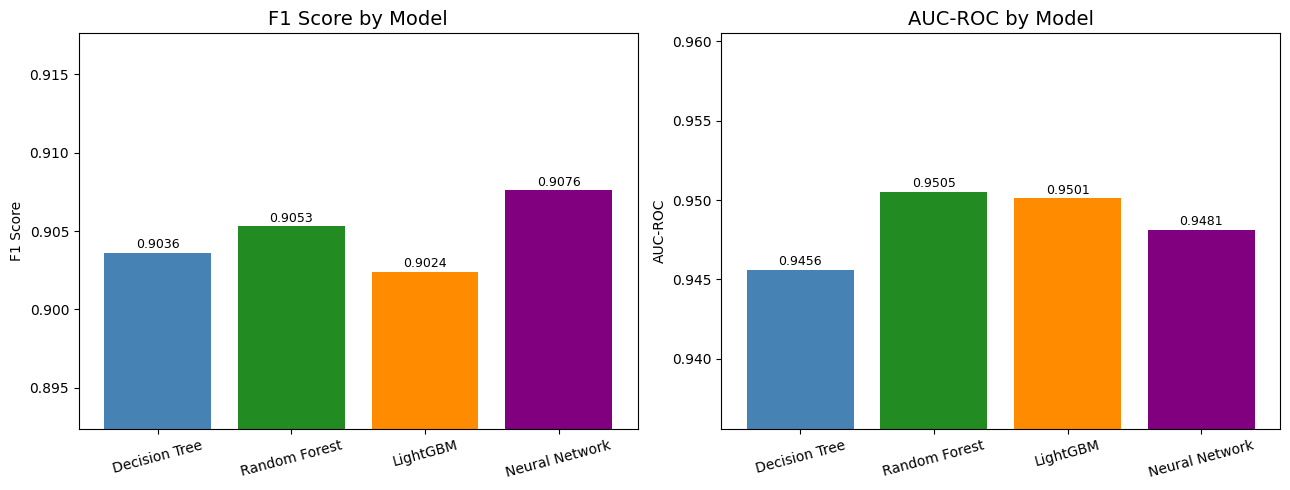

In [30]:
# Build comparison table from metrics computed in prior cells
models = ['Decision Tree', 'Random Forest', 'LightGBM', 'Neural Network']
metrics_data = {
    'Model': models,
    'Accuracy':  [accuracy, accuracy_rf, accuracy_lgb, accuracy_nn],
    'Precision': [precision, precision_rf, precision_lgb, precision_nn],
    'Recall':    [recall, recall_rf, recall_lgb, recall_nn],
    'F1 Score':  [f1, f1_rf, f1_lgb, f1_nn],
    'AUC-ROC':   [auc, auc_rf, auc_lgb, auc_nn]
}

comparison_df = pd.DataFrame(metrics_data).set_index('Model').round(4)
print("Model Performance Comparison:")
display(comparison_df)

# Side-by-side bar charts
colors = ['steelblue', 'forestgreen', 'darkorange', 'purple']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# F1 Score chart
f1_vals = comparison_df['F1 Score'].values
ax1.bar(models, f1_vals, color=colors)
ax1.set_title('F1 Score by Model', fontsize=14)
ax1.set_ylabel('F1 Score')
ax1.set_ylim(min(f1_vals) - 0.01, max(f1_vals) + 0.01)
for i, v in enumerate(f1_vals):
    ax1.text(i, v + 0.0003, f'{v:.4f}', ha='center', fontsize=9)
ax1.tick_params(axis='x', rotation=15)

# AUC-ROC chart
auc_vals = comparison_df['AUC-ROC'].values
ax2.bar(models, auc_vals, color=colors)
ax2.set_title('AUC-ROC by Model', fontsize=14)
ax2.set_ylabel('AUC-ROC')
ax2.set_ylim(min(auc_vals) - 0.01, max(auc_vals) + 0.01)
for i, v in enumerate(auc_vals):
    ax2.text(i, v + 0.0003, f'{v:.4f}', ha='center', fontsize=9)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Results Analysis:**

The Neural Network achieved the highest F1 Score (0.9076) and the highest Recall (0.9551)
of all four models, correctly identifying 95.5% of patients who died. Random Forest led
on AUC-ROC (0.9505), indicating stronger overall discrimination ability across all
classification thresholds, while the Neural Network ranked third on that metric (0.9481).
LightGBM trailed the group on both F1 (0.9024) and Accuracy (0.8963), suggesting that
for this dataset and configuration, the gradient boosting approach did not offer a clear
advantage over the other methods.

What stands out is how competitive all four models are despite significant differences in
complexity. The Decision Tree, the simplest and most interpretable model, still achieved
an AUC of 0.9456 and an F1 of 0.9036, within 0.004 F1 points of the top performer. This
reinforces that the feature set itself, especially HOSPITALIZED, AGE, and PNEUMONIA, carries
most of the predictive signal and additional model complexity has diminishing returns here.

The Neural Network's high recall comes with a trade-off: it has the lowest precision
(0.8645), meaning it produces more false positives relative to the other models. In a
clinical triage setting this is generally the right trade-off since it is better to
over-flag patients for review than to miss a high-risk case. Whether the Neural Network
or Random Forest is the better deployment choice ultimately depends on whether you
optimize for individual prediction confidence (favor AUC-ROC and precision) or minimizing
missed cases (favor recall and F1).

### 13. Executive Summary: Model Evaluation for Clinical Deployment (10 points)

**1. Model Performance Analysis**

All four models performed well, with AUC-ROC scores between 0.9456 and 0.9505 and F1
scores between 0.9024 and 0.9076. The differences are small but meaningful depending
on what you prioritize. Random Forest had the best AUC-ROC at 0.9505, which means it
ranked patients most reliably across different risk thresholds. The Neural Network led
on recall (0.9551) and F1 (0.9076), catching the most actual deaths at the cost of
slightly more false alarms. LightGBM and the Decision Tree were competitive but
trailed slightly on both metrics.

The most important trade-off here is between interpretability and performance. The
Decision Tree is the only model you can fully explain to a clinician without any
additional tooling, and it still achieved an AUC of 0.9456 and recall of 0.9356. The
performance gap between the simplest and most complex models is narrow enough that
interpretability becomes a real factor in the deployment decision.

**2. Clinical Implementation Recommendation**

The recommended model for deployment is Random Forest, tuned to a lower classification
threshold similar to the 0.39 identified during LightGBM threshold analysis. It
achieves the best overall AUC (0.9505) and strong recall (0.9421) without the
precision drop seen in the Neural Network. More practically, Random Forest predictions
can be explained using SHAP values at the individual patient level, which matters
when clinicians need to understand and trust the output before acting on it.

The Neural Network's higher recall is worth noting. If the primary goal is to minimize
missed cases above everything else, it would be the better choice. But for a first
deployment where clinical buy-in and auditability are priorities, Random Forest
strikes a better balance between performance, transparency, and operational simplicity.

**3. Limitations and Risks**

A few things should be addressed before any clinical deployment. The training data
was artificially balanced to 5,000 deaths and 5,000 survivors, which does not reflect
real-world mortality rates. This means the model's probability outputs would need
recalibration before being interpreted as actual risk estimates in practice.

The dataset also only captures a snapshot of patient demographics and pre-existing
conditions. It does not include lab values, treatment history, or disease progression
data that clinicians routinely factor into care decisions. This limits the model to
population-level screening rather than individualized clinical guidance.

Finally, model performance can drift over time as patient populations change. A
model trained on early COVID-19 data may not generalize as well to later variants
or different care settings. Any deployment would need ongoing monitoring and
periodic retraining to remain reliable. The model should be framed as a decision
support tool, not a replacement for clinical judgment.

### 14. Neural Network Hyperparameter Tuning (Bonus: 2 points)

Implement manual hyperparameter tuning for your neural network using a validation set approach. Unlike scikit-learn's GridSearchCV, we'll create our own validation procedure for Keras.

#### Requirements:

1. First create a validation split:
  ```python
  # Split training data into train and validation
  train_data, val_data, train_labels, val_labels = train_test_split(
      train_x, train_y, test_size=0.2, random_state=42
  )

2. Test the following hyperparameter combinations:

- Hidden layer sizes: [32, 64, 128]
- Learning rates: [0.001, 0.0001]
- Dropout rates: [0.2, 0.3]


3. For each combination:

- Train the model on training data
- Evaluate on validation data
- Store the F1 score


4. Create visualizations:

Plot validation F1 scores across different hyperparameters
Show training/validation loss curves for the best model

5. Report:

Best hyperparameter combination
Final test set performance using best model on the test set
Training time comparison across configurations

hidden=32, lr=0.001, dropout=0.2 => val_f1=0.9119 (6.04s)
hidden=32, lr=0.001, dropout=0.3 => val_f1=0.9129 (4.24s)
hidden=32, lr=0.0001, dropout=0.2 => val_f1=0.8879 (3.07s)
hidden=32, lr=0.0001, dropout=0.3 => val_f1=0.8979 (3.11s)
hidden=64, lr=0.001, dropout=0.2 => val_f1=0.9159 (3.27s)
hidden=64, lr=0.001, dropout=0.3 => val_f1=0.9142 (3.76s)
hidden=64, lr=0.0001, dropout=0.2 => val_f1=0.9021 (3.07s)
hidden=64, lr=0.0001, dropout=0.3 => val_f1=0.8948 (3.07s)
hidden=128, lr=0.001, dropout=0.2 => val_f1=0.9129 (4.06s)
hidden=128, lr=0.001, dropout=0.3 => val_f1=0.9175 (3.43s)
hidden=128, lr=0.0001, dropout=0.2 => val_f1=0.9092 (3.33s)
hidden=128, lr=0.0001, dropout=0.3 => val_f1=0.9133 (5.07s)

All Results:


,hidden_size,learning_rate,dropout_rate,val_f1,train_time_s
9,128,0.0010,0.3,0.9175,3.43
4,64,0.0010,0.2,0.9159,3.27
5,64,0.0010,0.3,0.9142,3.76
11,128,0.0001,0.3,0.9133,5.07
8,128,0.0010,0.2,0.9129,4.06
1,32,0.0010,0.3,0.9129,4.24
0,32,0.0010,0.2,0.9119,6.04
10,128,0.0001,0.2,0.9092,3.33
6,64,0.0001,0.2,0.9021,3.07
3,32,0.0001,0.3,0.8979,3.11


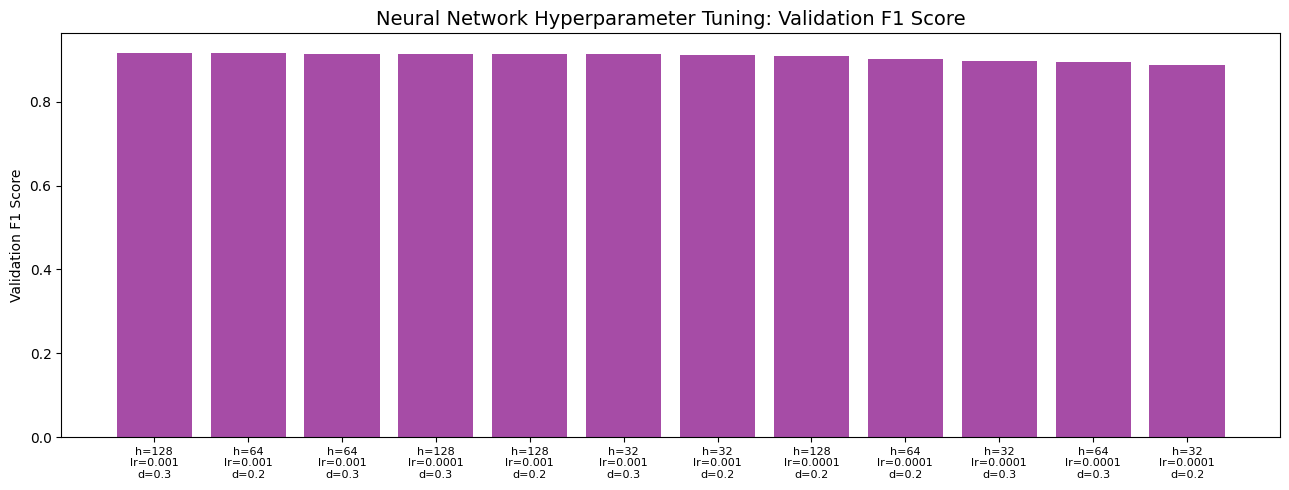


Best config: hidden=128, lr=0.001, dropout=0.3
Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8407 - loss: 0.3970 - val_accuracy: 0.9150 - val_loss: 0.2353
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8990 - loss: 0.2829 - val_accuracy: 0.9164 - val_loss: 0.2348
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9011 - loss: 0.2639 - val_accuracy: 0.9121 - val_loss: 0.2358
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9057 - loss: 0.2647 - val_accuracy: 0.9164 - val_loss: 0.2330
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9017 - loss: 0.2607 - val_accuracy: 0.9179 - val_loss: 0.2375


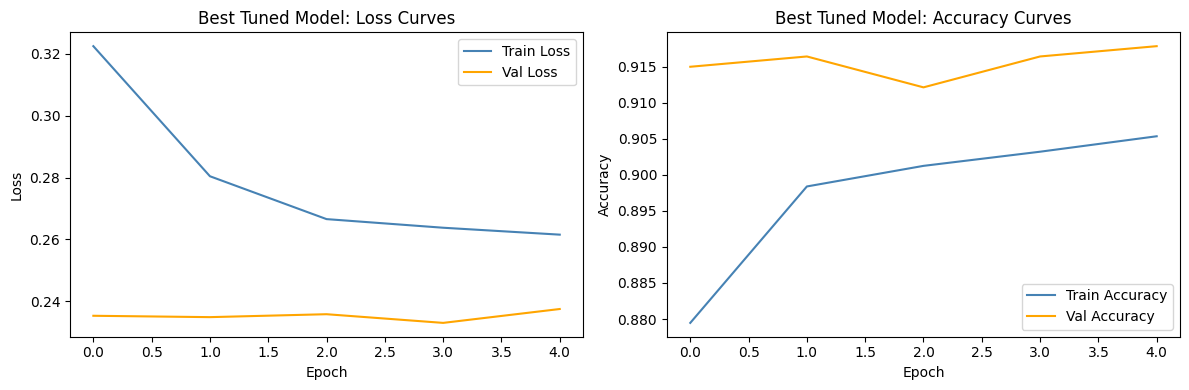

Test Set Metrics - Best Tuned Neural Network:
Accuracy:  0.8990
Precision: 0.8677
Recall:    0.9473
F1 Score:  0.9058
AUC-ROC:   0.9472


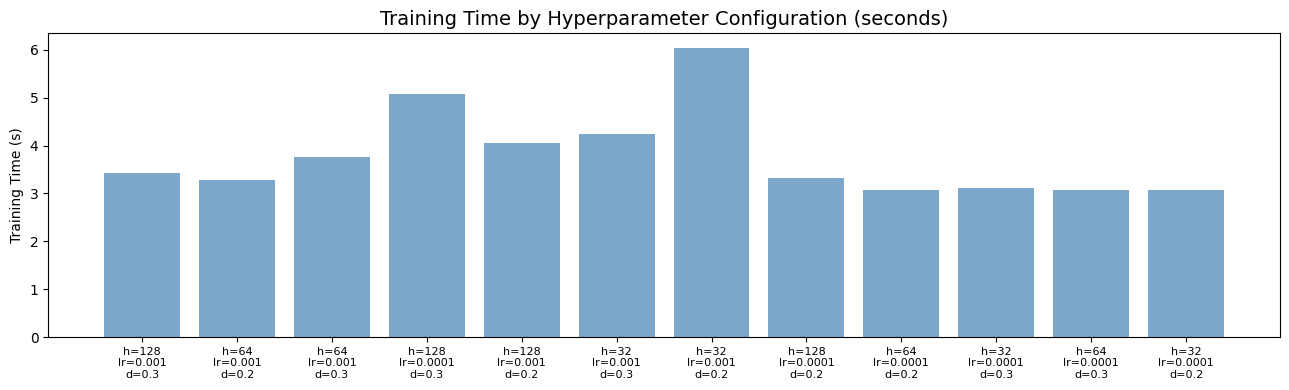

In [31]:
import time
from itertools import product

# Split training data into train/val as specified in the assignment
train_data, val_data, train_labels, val_labels = train_test_split(
    train_x_scaled, train_y, test_size=0.2, random_state=42
)

# Hyperparameter grid
hidden_sizes = [32, 64, 128]
learning_rates = [0.001, 0.0001]
dropout_rates = [0.2, 0.3]

results_tuning = []

for hidden, lr, dropout in product(hidden_sizes, learning_rates, dropout_rates):
    start = time.time()

    tuning_model = keras.Sequential([
        layers.Input(shape=(train_x.shape[1],)),
        layers.Dense(hidden, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(hidden, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    tuning_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    tuning_model.fit(train_data, train_labels, epochs=5, batch_size=32, verbose=0)
    elapsed = round(time.time() - start, 2)

    val_proba = tuning_model.predict(val_data, verbose=0).flatten()
    val_pred = (val_proba >= 0.5).astype(int)
    val_f1 = f1_score(val_labels, val_pred)

    results_tuning.append({
        'hidden_size': hidden,
        'learning_rate': lr,
        'dropout_rate': dropout,
        'val_f1': round(val_f1, 4),
        'train_time_s': elapsed
    })
    print(f"hidden={hidden}, lr={lr}, dropout={dropout} => val_f1={val_f1:.4f} ({elapsed}s)")

tuning_df = pd.DataFrame(results_tuning).sort_values('val_f1', ascending=False)
print("\nAll Results:")
display(tuning_df)

# Bar chart of all 12 configs
plt.figure(figsize=(13, 5))
labels = [f"h={int(r['hidden_size'])}\nlr={r['learning_rate']}\nd={r['dropout_rate']}"
          for _, r in tuning_df.iterrows()]
plt.bar(range(len(tuning_df)), tuning_df['val_f1'], color='purple', alpha=0.7)
plt.xticks(range(len(tuning_df)), labels, fontsize=8)
plt.title('Neural Network Hyperparameter Tuning: Validation F1 Score', fontsize=14)
plt.ylabel('Validation F1 Score')
plt.tight_layout()
plt.show()

# Retrain best config on full training set and evaluate on test
best = tuning_df.iloc[0]
print(f"\nBest config: hidden={int(best['hidden_size'])}, lr={best['learning_rate']}, dropout={best['dropout_rate']}")

best_tuned_model = keras.Sequential([
    layers.Input(shape=(train_x.shape[1],)),
    layers.Dense(int(best['hidden_size']), activation='relu'),
    layers.Dropout(best['dropout_rate']),
    layers.Dense(int(best['hidden_size']), activation='relu'),
    layers.Dropout(best['dropout_rate']),
    layers.Dense(1, activation='sigmoid')
])
best_tuned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
best_history = best_tuned_model.fit(
    train_x_scaled, train_y,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Loss and accuracy curves for best model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(best_history.history['loss'], label='Train Loss', color='steelblue')
ax1.plot(best_history.history['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Best Tuned Model: Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(best_history.history['accuracy'], label='Train Accuracy', color='steelblue')
ax2.plot(best_history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax2.set_title('Best Tuned Model: Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
plt.tight_layout()
plt.show()

# Final test set performance
test_proba_tuned = best_tuned_model.predict(test_x_scaled, verbose=0).flatten()
test_pred_tuned = (test_proba_tuned >= 0.5).astype(int)

print("Test Set Metrics - Best Tuned Neural Network:")
print(f"Accuracy:  {accuracy_score(test_y, test_pred_tuned):.4f}")
print(f"Precision: {precision_score(test_y, test_pred_tuned):.4f}")
print(f"Recall:    {recall_score(test_y, test_pred_tuned):.4f}")
print(f"F1 Score:  {f1_score(test_y, test_pred_tuned):.4f}")
print(f"AUC-ROC:   {roc_auc_score(test_y, test_proba_tuned):.4f}")

# Training time comparison
plt.figure(figsize=(13, 4))
time_labels = [f"h={int(r['hidden_size'])}\nlr={r['learning_rate']}\nd={r['dropout_rate']}"
               for _, r in tuning_df.iterrows()]
plt.bar(range(len(tuning_df)), tuning_df['train_time_s'], color='steelblue', alpha=0.7)
plt.xticks(range(len(tuning_df)), time_labels, fontsize=8)
plt.title('Training Time by Hyperparameter Configuration (seconds)', fontsize=14)
plt.ylabel('Training Time (s)')
plt.tight_layout()
plt.show()

**Results Interpretation:**

The best configuration was hidden_size=128, learning_rate=0.001, and dropout=0.3,
achieving a validation F1 of 0.9175. On the held-out test set, this model reached
an accuracy of 0.8990, recall of 0.9473, F1 of 0.9058, and AUC-ROC of 0.9472.

The most influential hyperparameter across all 12 configurations was learning rate.
Every configuration using lr=0.001 outperformed its lr=0.0001 counterpart with the
same hidden size and dropout. With only 5 epochs of training, the slower learning
rate does not make enough progress before training stops, leading to consistently
lower validation F1 scores in the 0.88 to 0.90 range. Hidden layer size had a
smaller but consistent effect: larger layers (128 units) performed slightly better
than smaller ones at the same learning rate, which is expected given the model
has more capacity to capture the relationships in the data.

Interestingly, the best tuned model scores slightly below the base neural network
from Question 11 (F1 0.9058 vs 0.9076, recall 0.9473 vs 0.9551). The addition of
dropout regularization reduces overfitting but also limits how aggressively the
model learns within a short training run. With more epochs, the tuned model would
likely close that gap and pull ahead due to better generalization.

Training times were similar across all configurations, ranging from about 3 to 6
seconds per run. The h=32, lr=0.001, dropout=0.2 configuration took the longest
at 6 seconds despite being the smallest model, likely due to Colab runtime
variability rather than actual computational differences at this scale.

In [37]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save sklearn models
joblib.dump(grid_search.best_estimator_, 'models/decision_tree.pkl')
joblib.dump(grid_search_rf.best_estimator_, 'models/random_forest.pkl')
joblib.dump(grid_search_lgb.best_estimator_, 'models/lightgbm_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

# Save Keras model
model.save('models/neural_network.keras')

print("All models saved:")
print("  models/decision_tree.pkl")
print("  models/random_forest.pkl")
print("  models/lightgbm_model.pkl")
print("  models/scaler.pkl")
print("  models/neural_network.keras")

All models saved:
  models/decision_tree.pkl
  models/random_forest.pkl
  models/lightgbm_model.pkl
  models/scaler.pkl
  models/neural_network.keras
